<a href="https://colab.research.google.com/github/mumshadrifat/About-Me/blob/main/hyper_param_cnn.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from keras.models import Sequential
import pandas as pd
from keras.layers import Dense, Conv1D, Flatten
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
import matplotlib.pyplot as plt
import numpy as np

# from google.colab import files
# uploaded = files.upload()

In [ ]:
print (uploaded)

{'mego.csv - mego.csv.csv': b'february,march,fminusi,tminusi,theta,ego\r\n0.202785543,0.218398232,-0.062856003,0.015612689,0.5,-0.248388193\r\n0.13992954,0.207282653,0.056125438,0.067353113,0.5,1.2000461\r\n0.196054978,0.121935996,0.02491434,-0.074118982,0.5,-2.974952658\r\n0.220969318,0.157971288,-0.092847105,-0.06299803,0.5,0.67851367\r\n0.128122213,0.084076645,-0.036186093,-0.044045568,0.5,1.21719601\r\n0.09193612,0.048724907,0.152713654,-0.043211213,0.5,-0.282955793\r\n0.244649774,0.174258671,-0.081594102,-0.070391103,0.5,0.862698422\r\n0.163055672,0.251473103,-0.049861357,0.088417431,0.5,-1.773265637\r\n0.113194315,0.159182117,0.048842998,0.045987802,0.5,0.941543392\r\n0.162037313,0.071184777,-0.047226624,-0.090852536,0.5,1.923756735\r\n0.114810689,0.244901895,0.039509319,0.130091206,0.5,3.292671433\r\n0.154320008,0.211726118,-0.06849531,0.05740611,0.5,-0.838102784\r\n0.085824698,0.109735963,0.099856465,0.023911265,0.5,0.239456354\r\n0.185681163,0.126270169,0.185392573,-0.05941099

In [ ]:
#data=np.genfromtxt("fish_cost.csv",delimiter=",")
data=pd.read_csv("mego.csv",delimiter=",")
#data=np.asarray(data)
print(data)
data=np.asarray(data)
x=data[:,:-1]
x=np.asarray(x,float)
y=data[:,-1]
y=np.asarray(y,float)

print(x.shape)
print(data)
#print(x)
#print(y)

     february     march   fminusi   tminusi  theta       ego
0    0.202786  0.218398 -0.062856  0.015613    0.5 -0.248388
1    0.139930  0.207283  0.056125  0.067353    0.5  1.200046
2    0.196055  0.121936  0.024914 -0.074119    0.5 -2.974953
3    0.220969  0.157971 -0.092847 -0.062998    0.5  0.678514
4    0.128122  0.084077 -0.036186 -0.044046    0.5  1.217196
..        ...       ...       ...       ...    ...       ...
186  0.354397  0.058353 -0.174544 -0.296044    0.5  1.696104
187  0.179853  0.040814 -0.154685 -0.139039    0.5  0.898853
188  0.025168  0.025168  0.089227  0.000000    0.5  0.000000
189  0.114396  0.060007  0.232132 -0.054388    0.5 -0.234298
190  0.346527  0.049533 -0.346527 -0.296995    0.5  0.857060

[191 rows x 6 columns]
(191, 5)
[[ 0.20278554  0.21839823 -0.062856    0.01561269  0.5        -0.24838819]
 [ 0.13992954  0.20728265  0.05612544  0.06735311  0.5         1.2000461 ]
 [ 0.19605498  0.121936    0.02491434 -0.07411898  0.5        -2.97495266]
 ...
 [ 0.

In [ ]:
x = x.reshape(x.shape[0], 5,-1)
print(x.shape)

xtrain, xtest, ytrain, ytest=train_test_split(x, y, test_size=0.15)

model = Sequential()
model.add(Conv1D(32, 2, activation="relu", input_shape=(5,1)))
model.add(Flatten())
model.add(Dense(64, activation="relu"))
model.add(Dense(1,activation="linear"))
model.compile(loss="mse", optimizer="adam")
model.summary()
model.fit(xtrain, ytrain, batch_size=12,epochs=200, verbose=0)

ypred = model.predict(xtest)
#print(model.evaluate(xtrain, ytrain))
print("MSE: %.4f" % mean_squared_error(ytest, ypred))

(191, 5, 1)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 4, 32)          │            96 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 8,417 (32.88 KB)

 Trainable params: 8,417 (32.88 KB)

 Non-trainable params: 0 (0.00 B)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 87ms/step
MSE: 54.4549


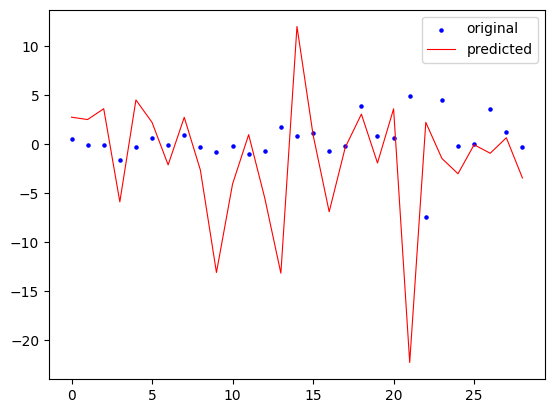

In [ ]:
x_ax = range(len(ypred))
plt.scatter(x_ax, ytest, s=5, color="blue", label="original")
plt.plot(x_ax, ypred, lw=0.8, color="red", label="predicted")
plt.legend()
plt.show()